Fase 0: Setup

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

LABEL_NAMES = ['Human', 'DeepSeek', 'Grok', 'Claude', 'Gemini', 'ChatGPT']
DATA_DIR    = '/kaggle/input/competitions/malto-recruitment-hackathon/'


In [2]:
train = pd.read_csv(DATA_DIR + 'train.csv')
test  = pd.read_csv(DATA_DIR + 'test.csv')

print(f"Train: {train.shape}  |  null: {train.isnull().sum().sum()}")
print(f"Test:  {test.shape}   |  null: {test.isnull().sum().sum()}")
print(train.head(3))


Train: (2400, 2)  |  null: 0
Test:  (600, 2)   |  null: 0
                                                TEXT  LABEL
0  Dear state senator, There should be a change i...      0
1  A star's life cycle begins in a nebula and pro...      1
2  Limiting the usage of has a variety advantages...      0


LABEL
Human       1520
DeepSeek      80
Grok         160
Claude        80
Gemini       240
ChatGPT      320
Name: count, dtype: int64


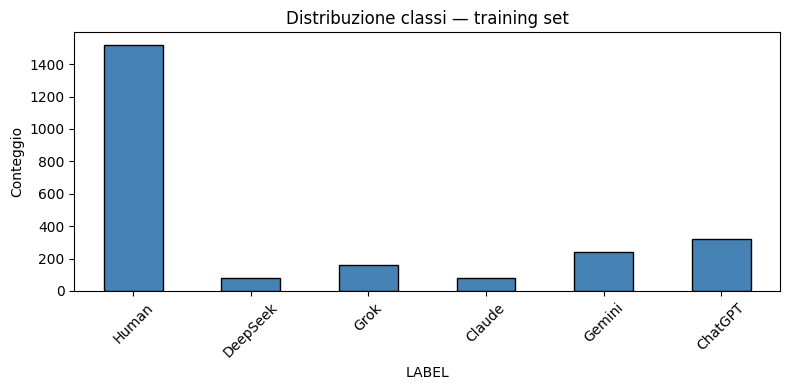

In [3]:
print(train['LABEL'].value_counts().sort_index().rename(index=dict(enumerate(LABEL_NAMES))))

plt.figure(figsize=(8, 4))
train['LABEL'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.xticks(range(6), LABEL_NAMES, rotation=45)
plt.title('Distribuzione classi — training set')
plt.ylabel('Conteggio')
plt.tight_layout()
plt.show()


In [4]:
dup_exact = train.duplicated(subset=['TEXT']).sum()
norm      = train['TEXT'].str.lower().str.replace(r'\s+', ' ', regex=True).str.strip()
dup_norm  = norm.duplicated().sum()
conflicts = train.groupby(norm)['LABEL'].nunique()
print(f"Duplicati esatti:              {dup_exact}")
print(f"Duplicati dopo normalizzazione: {dup_norm}")
print(f"Testi con label contrastanti:  {(conflicts > 1).sum()}")


Duplicati esatti:              0
Duplicati dopo normalizzazione: 0
Testi con label contrastanti:  0


In [7]:
for label, name in enumerate(LABEL_NAMES):
    print(f"\n{'='*50}\nLabel {label} — {name}\n{'='*50}")
    for i, text in enumerate(train[train['LABEL'] == label]['TEXT'].head(2)):
        print(f"\n[Esempio {i+1}]\n{text[:300]}...")



Label 0 — Human

[Esempio 1]
Dear state senator, There should be a change in the Electoral College. It should be changed to electing presidents by popular vote. It is our right to vote for someone who would actually make changes in our society and make our ilves different. The fact that we have to vote electors for those electo...

[Esempio 2]
Limiting the usage of has a variety advantages. From having a less expensive life, to less air ollution, and overall a generally happier life. Thinking about all the xcess and stress that comes with a car is tiring. Not to mention the hazardous it had on our lives. Would it not be nice to just take ...

Label 1 — DeepSeek

[Esempio 1]
A star's life cycle begins in a nebula and progresses through stages determined by its mass, ending as a white dwarf, neutron star, or black hole....

[Esempio 2]
Year-round research in Antarctic bases is crucial for collecting continuous data on ice sheet dynamics and atmospheric conditions that influence global s

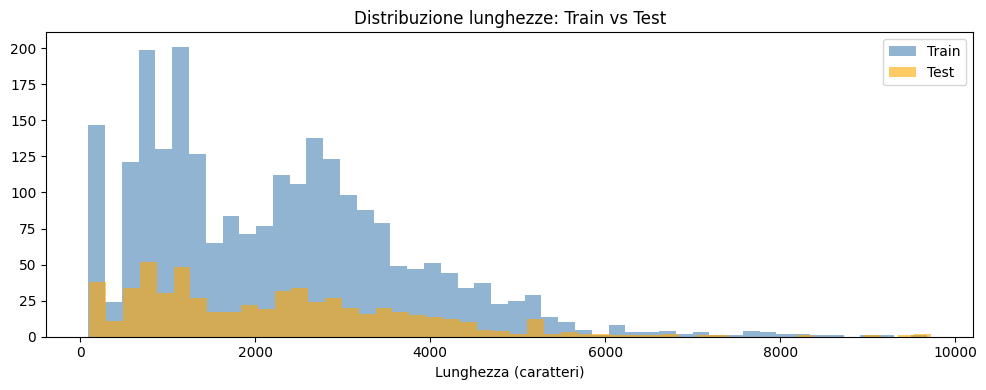

          text_len  word_count
Human       2510.6       450.9
DeepSeek     560.0        83.1
Grok         414.5        55.6
Claude      3358.7       375.6
Gemini      2818.7       419.9
ChatGPT     1485.2       179.4


In [5]:
# Istogramma lunghezze
plt.figure(figsize=(10, 4))
plt.hist(train['TEXT'].str.len(), bins=50, alpha=0.6, label='Train', color='steelblue')
plt.hist(test['TEXT'].str.len(),  bins=50, alpha=0.6, label='Test',  color='orange')
plt.xlabel('Lunghezza (caratteri)')
plt.title('Distribuzione lunghezze: Train vs Test')
plt.legend()
plt.tight_layout()
plt.show()

# Stats per classe
stats = (train.assign(text_len=train['TEXT'].str.len(),
                      word_count=train['TEXT'].str.split().str.len())
               .groupby('LABEL')[['text_len', 'word_count']].mean().round(1))
stats.index = LABEL_NAMES
print(stats)


In [6]:
def stylistic_features(text):
    n = max(len(text), 1)
    return pd.Series({
        'punct':    len([c for c in text if c in '.,;:!?']) / n,
        'upper':    sum(c.isupper() for c in text) / n,
        'markdown': len(re.findall(r'[#\*\-]', text)) / n,
    })

style = train['TEXT'].apply(stylistic_features)
style['LABEL'] = train['LABEL']
print(style.groupby('LABEL').mean().round(4).rename(index=dict(enumerate(LABEL_NAMES))))


           punct   upper  markdown
LABEL                             
Human     0.0207  0.0547    0.0013
DeepSeek  0.0162  0.0120    0.0017
Grok      0.0175  0.0135    0.0016
Claude    0.0273  0.0241    0.0014
Gemini    0.0150  0.0099    0.0014
ChatGPT   0.0267  0.0043    0.0015


In [8]:
def raw_text(text):
    """Normalizza solo gli spazi multipli — preserva maiuscole e punteggiatura."""
    return re.sub(r'\s+', ' ', text).strip()

def lower_text(text):
    """Solo lowercase — usato per word TF-IDF dello specialista."""
    return text.lower()

def clean_text(text):
    """Lowercase + rimuove URL e caratteri non stampabili — usato per il modello principale."""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^\x20-\x7E\n]', '', text)
    return re.sub(r'\s+', ' ', text).strip()

for df in [train, test]:
    df['raw_text']   = df['TEXT'].apply(raw_text)
    df['lower_text'] = df['TEXT'].apply(lower_text)
    df['clean_text'] = df['TEXT'].apply(clean_text)

print("Testi vuoti dopo clean_text — train:",
      (train['clean_text'].str.len() == 0).sum(),
      "| test:", (test['clean_text'].str.len() == 0).sum())


Testi vuoti dopo clean_text — train: 0 | test: 0


## Osservazioni EDA

### Distribuzione classi
- Dataset fortemente sbilanciato: Human=1520 (63%), DeepSeek=80 (3%), Claude=80 (3%)
- `class_weight='balanced'` è obbligatorio

### Lunghezze
- DeepSeek (~414 car.) e Grok (~560 car.) sono i più corti — segnale discriminativo forte
- Claude (~3358 car.) è il più lungo

### Feature stilistiche
- Human ha più maiuscole (errori/enfasi): upper≈0.055
- ChatGPT ha pochissime maiuscole extra: upper≈0.004
- Claude e ChatGPT usano più punteggiatura

### A occhio
- Human: errori di battitura, stile informale
- DeepSeek/Grok: stile enciclopedico, frasi brevi
- Claude: frasi separate, stile a lista implicita
- ChatGPT: tono accademico, vocabolario ricercato


In [9]:
def calc_features(df):
    df = df.copy()
    df['text_len']      = df['TEXT'].str.len()
    df['word_count']    = df['TEXT'].str.split().str.len()
    df['sent_count']    = df['TEXT'].str.count(r'[.!?]') + 1
    df['avg_w_sent']    = df['word_count'] / df['sent_count']
    df['punct_density'] = df['TEXT'].apply(
        lambda t: len([c for c in t if c in '.,;:!?']) / max(len(t), 1))
    df['upper_ratio']   = df['TEXT'].apply(
        lambda t: sum(c.isupper() for c in t) / max(len(t), 1))
    return df

train = calc_features(train)
test  = calc_features(test)

feat_cols = ['text_len', 'word_count', 'sent_count', 'avg_w_sent', 'punct_density', 'upper_ratio']
y_train   = train['LABEL']

print(train.groupby('LABEL')[feat_cols].mean().round(3).rename(index=dict(enumerate(LABEL_NAMES))))


          text_len  word_count  sent_count  avg_w_sent  punct_density  \
LABEL                                                                   
Human     2510.599     450.869      31.135      15.904          0.021   
DeepSeek   560.025      83.075       4.488      14.647          0.016   
Grok       414.469      55.644       3.450      14.936          0.017   
Claude    3358.688     375.625      73.775       5.401          0.027   
Gemini    2818.662     419.875      20.879      20.560          0.015   
ChatGPT   1485.244     179.419      10.934      16.191          0.027   

          upper_ratio  
LABEL                  
Human           0.055  
DeepSeek        0.012  
Grok            0.013  
Claude          0.024  
Gemini          0.010  
ChatGPT         0.004  


In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe_p1 = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=50000, ngram_range=(1, 2), sublinear_tf=True)),
    ('clf',   LinearSVC(class_weight='balanced', max_iter=2000))
])

oof_p1 = cross_val_predict(pipe_p1, train['clean_text'], y_train, cv=cv, n_jobs=-1)
print(f"Baseline OOF Macro F1: {f1_score(y_train, oof_p1, average='macro'):.4f}")
print(classification_report(y_train, oof_p1, target_names=LABEL_NAMES))


Baseline OOF Macro F1: 0.8887
              precision    recall  f1-score   support

       Human       1.00      1.00      1.00      1520
    DeepSeek       0.81      0.36      0.50        80
        Grok       0.76      0.95      0.85       160
      Claude       1.00      1.00      1.00        80
      Gemini       1.00      0.99      0.99       240
     ChatGPT       0.99      0.99      0.99       320

    accuracy                           0.97      2400
   macro avg       0.93      0.88      0.89      2400
weighted avg       0.97      0.97      0.97      2400



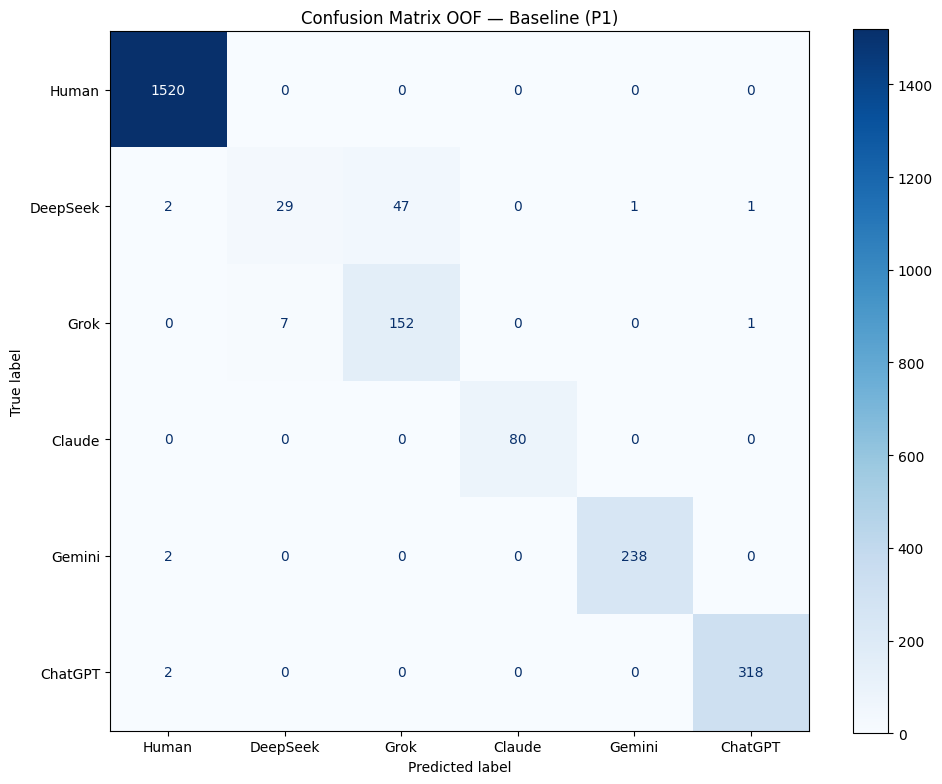


Totale errori: 63/2400 (2.6%)
LABEL
DeepSeek    51
Grok         8
Gemini       2
ChatGPT      2
Name: count, dtype: int64

DeepSeek → Grok: 47 testi

--- Esempio 1 ---
A star's life cycle begins in a nebula and progresses through stages determined by its mass, ending as a white dwarf, neutron star, or black hole.

--- Esempio 2 ---
Nuclear fission releases immense energy by splitting heavy atoms, a process harnessed in reactors but also requiring careful management of radioactive waste products.

--- Esempio 3 ---
Aged Gouda from the Netherlands develops a rich, caramel-like flavor and hard texture over several years.


In [11]:
cm = confusion_matrix(y_train, oof_p1)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(cm, display_labels=LABEL_NAMES).plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix OOF — Baseline (P1)')
plt.tight_layout()
plt.show()

# Error analysis
oof_df         = train[['TEXT', 'LABEL']].copy()
oof_df['pred'] = oof_p1
errors         = oof_df[oof_df['LABEL'] != oof_df['pred']]
print(f"\nTotale errori: {len(errors)}/{len(train)} ({len(errors)/len(train)*100:.1f}%)")
print(errors['LABEL'].map(dict(enumerate(LABEL_NAMES))).value_counts())

# DeepSeek → Grok: principale fonte di errori
ds_grok = errors[(errors['LABEL'] == 1) & (errors['pred'] == 2)]
print(f"\nDeepSeek → Grok: {len(ds_grok)} testi")
for i, (_, row) in enumerate(ds_grok.head(3).iterrows()):
    print(f"\n--- Esempio {i+1} ---\n{row['TEXT'][:400]}")


In [12]:
pipe_p1.fit(train['clean_text'], y_train)
y_pred = pipe_p1.predict(test['clean_text'])

pd.DataFrame({'ID': test['Unnamed: 0'], 'LABEL': y_pred.astype(int)}).to_csv('submission_baseline.csv', index=False)
print("submission_baseline.csv ✓")
print(pd.Series(y_pred).value_counts().sort_index().rename(index=dict(enumerate(LABEL_NAMES))))


submission_baseline.csv ✓
Human       380
DeepSeek     11
Grok         47
Claude       20
Gemini       61
ChatGPT      81
Name: count, dtype: int64


In [13]:
results = pd.DataFrame([
    {'nome': 'baseline',   'oof': 0.8887, 'f1_ds': 0.50, 'f1_grok': 0.85, 'submitted': True},
    {'nome': 'router_6.4', 'oof': 0.9165, 'f1_ds': 0.64, 'f1_grok': 0.87, 'submitted': True},
])
print(results.to_string(index=False))


      nome    oof  f1_ds  f1_grok  submitted
  baseline 0.8887   0.50     0.85       True
router_6.4 0.9165   0.64     0.87       True


In [14]:
cv_global  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_global = np.zeros(len(y_train), dtype=int)

for fold, (tr_idx, val_idx) in enumerate(cv_global.split(train['clean_text'], y_train)):

    # Modello principale sul fold train
    main_f = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=50000, ngram_range=(1, 2), sublinear_tf=True)),
        ('clf',   LinearSVC(class_weight='balanced', max_iter=2000))
    ])
    main_f.fit(train['clean_text'].iloc[tr_idx], y_train.iloc[tr_idx])
    preds_val = main_f.predict(train['clean_text'].iloc[val_idx])

    # Specialista DeepSeek/Grok — allena solo sulle classi [1,2] del fold train
    mask_tr   = train['LABEL'].iloc[tr_idx].isin([1, 2])
    tr_12_idx = np.array(tr_idx)[mask_tr.values]

    tw_f = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), sublinear_tf=True)
    tc_f = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), max_features=100000, sublinear_tf=True)
    sc_f = StandardScaler()

    Xw_f = tw_f.fit_transform(train['lower_text'].iloc[tr_12_idx])
    Xc_f = tc_f.fit_transform(train['raw_text'].iloc[tr_12_idx])
    Xm_f = sc_f.fit_transform(train.loc[train.index[tr_12_idx], feat_cols])
    X_f  = sparse.hstack([Xw_f, Xc_f, sparse.csr_matrix(Xm_f)])

    spec_f = LinearSVC(class_weight='balanced', max_iter=2000)
    spec_f.fit(X_f, y_train.iloc[tr_12_idx])

    # Routing: passa allo specialista le predizioni [1,2] del fold val
    mask_r         = np.isin(preds_val, [1, 2])
    val_router_idx = np.array(val_idx)[mask_r]

    if len(val_router_idx) > 0:
        Xw_r = tw_f.transform(train['lower_text'].iloc[val_router_idx])
        Xc_r = tc_f.transform(train['raw_text'].iloc[val_router_idx])
        Xm_r = sc_f.transform(train.loc[train.index[val_router_idx], feat_cols])
        X_r  = sparse.hstack([Xw_r, Xc_r, sparse.csr_matrix(Xm_r)])
        preds_val[mask_r] = spec_f.predict(X_r)

    oof_global[val_idx] = preds_val
    print(f"  fold {fold+1}/5 ✓")

print(f"\nMacro F1 con router: {f1_score(y_train, oof_global, average='macro'):.4f}  (baseline: 0.8887)")
print(classification_report(y_train, oof_global, target_names=LABEL_NAMES))


  fold 1/5 ✓
  fold 2/5 ✓
  fold 3/5 ✓
  fold 4/5 ✓
  fold 5/5 ✓

Macro F1 con router: 0.9165  (baseline: 0.8887)
              precision    recall  f1-score   support

       Human       1.00      1.00      1.00      1520
    DeepSeek       0.82      0.53      0.64        80
        Grok       0.82      0.94      0.87       160
      Claude       1.00      1.00      1.00        80
      Gemini       1.00      0.99      0.99       240
     ChatGPT       0.99      0.99      0.99       320

    accuracy                           0.98      2400
   macro avg       0.94      0.91      0.92      2400
weighted avg       0.98      0.98      0.98      2400



In [15]:
# Modello principale su tutto il train
pipe_main = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=50000, ngram_range=(1, 2), sublinear_tf=True)),
    ('clf',   LinearSVC(class_weight='balanced', max_iter=2000))
])
pipe_main.fit(train['clean_text'], y_train)
test_preds = pipe_main.predict(test['clean_text'])

# Specialista su tutte le classi [1,2]
mask_12  = train['LABEL'].isin([1, 2])
tw_final = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), sublinear_tf=True)
tc_final = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), max_features=100000, sublinear_tf=True)
sc_final = StandardScaler()

Xw_12 = tw_final.fit_transform(train['lower_text'][mask_12])
Xc_12 = tc_final.fit_transform(train['raw_text'][mask_12])
Xm_12 = sc_final.fit_transform(train.loc[mask_12, feat_cols])
X_12  = sparse.hstack([Xw_12, Xc_12, sparse.csr_matrix(Xm_12)])

spec_final = LinearSVC(class_weight='balanced', max_iter=2000)
spec_final.fit(X_12, y_train[mask_12])

# Routing sul test
mask_r = np.isin(test_preds, [1, 2])
Xw_r = tw_final.transform(test['lower_text'][mask_r])
Xc_r = tc_final.transform(test['raw_text'][mask_r])
Xm_r = sc_final.transform(test.loc[mask_r, feat_cols])
X_r  = sparse.hstack([Xw_r, Xc_r, sparse.csr_matrix(Xm_r)])
test_preds[mask_r] = spec_final.predict(X_r)

pd.DataFrame({'ID': test['Unnamed: 0'], 'LABEL': test_preds.astype(int)}).to_csv('submission_router.csv', index=False)
print("submission_router.csv ✓")
print(pd.Series(test_preds).value_counts().sort_index().rename(index=dict(enumerate(LABEL_NAMES))))


submission_router.csv ✓
Human       380
DeepSeek     14
Grok         44
Claude       20
Gemini       61
ChatGPT      81
Name: count, dtype: int64


In [16]:
oof_score = f1_score(y_train, oof_global, average='macro')
report    = classification_report(y_train, oof_global, target_names=LABEL_NAMES, output_dict=True)

print(f"OOF Macro F1:  {oof_score:.4f}  {'✅' if oof_score >= 0.8887 else '❌'}")
print(f"F1 DeepSeek:   {report['DeepSeek']['f1-score']:.2f}  {'✅' if report['DeepSeek']['f1-score'] >= 0.50 else '❌'}")
print(f"F1 Grok:       {report['Grok']['f1-score']:.2f}  {'✅' if report['Grok']['f1-score'] >= 0.85 else '❌'}")
print(f"F1 Human:      {report['Human']['f1-score']:.2f}  {'✅' if report['Human']['f1-score'] >= 0.99 else '❌'}")

sub       = pd.read_csv('submission_router.csv')
human_pct = sub['LABEL'].value_counts(normalize=True).get(0, 0)
print(f"Human nel test: {human_pct:.1%}  {'✅' if 0.58 <= human_pct <= 0.68 else '⚠️'}")


OOF Macro F1:  0.9165  ✅
F1 DeepSeek:   0.64  ✅
F1 Grok:       0.87  ✅
F1 Human:      1.00  ✅
Human nel test: 63.3%  ✅


## Osservazioni Error Analysis

### Numeri chiave
- Totale errori baseline: 63/2400 (2.6%)
- DeepSeek: 51 errori (47 classificati come Grok)
- Tutte le altre classi: quasi perfette

### Causa principale
I testi DeepSeek erroneamente classificati come Grok sono **frasi singole molto brevi**  
(es. "A star's life cycle begins in a nebula...").  
Con poco testo, il TF-IDF non trova abbastanza segnale discriminativo.

### Soluzione implementata (router)
- Specialista dedicato alle classi [1,2] con word + char TF-IDF + feature handcrafted (lunghezza, upper_ratio, ...)
- Il router intercetta le predizioni [1,2] del modello principale e le passa allo specialista
- Risultato: F1 DeepSeek 0.50 → 0.64, OOF 0.8887 → 0.9165
